In [14]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from matplotlib import colormaps
import pandas as pd

In [7]:
plt.style.use('ggplot')

## Maximum Likelihood Estimation of Shewed Normal Distribution

The idea in section is to model wind speed using a skewed normal distribution. Furthermore, we will assume that the skew, $/alpha$, is a function of the mean wind speed, $\mu$. This means we will have the skewed normal distribution

$f(x|\mu, \sigma) = \frac{2}{\sigma}\phi\left(\frac{x-\mu}{\sigma}\right)\Phi\left(\alpha(x)\left(\frac{x-\mu}{\sigma}\right)\right)$


where $\phi$ is the standard normal pdf and $\Phi$ is the standard normal cdf. The parameters are:
- $\mu$ is the location parameter
- $\sigma$ is the scale parameter
- $\alpha(x|\mu,\sigma) = g(\frac{x - \mu}{\sigma})$ is the shape parameter.

We assume the shape parameter can be modeled as a linear function:

$\alpha(x) = \alpha_0 + \alpha_1 \frac{x - \mu}{\sigma}$

This results in the following distribution

$f(x|\mu, \sigma, \alpha_0, \alpha_1) = \frac{2}{\sigma}\phi\left(z\right)\Phi\left(\alpha(z)\left(z\right)\right) \text{ where } z = \frac{x - \mu}{\sigma}$


## Data Visualization

The basic idea of this model is that wind speed is essentially a random walk, except that when the wind speed is high it is more likely that it will decrease and when the wind speed is low it is more likely that it will increase. In this section, we will look at some real wind speed data and plot it along with the distribution of the change of wind speed given different wind speeds. The data is from the Kelmarsh wind farm in the UK. The data is from the year 2016 and is sampled at 10 minute intervals, [https://zenodo.org/records/5841834#.YgpBQ_so-V7](https://zenodo.org/records/5841834#.YgpBQ_so-V7)

In [4]:
df = pd.read_parquet("wind_speed.parquet")

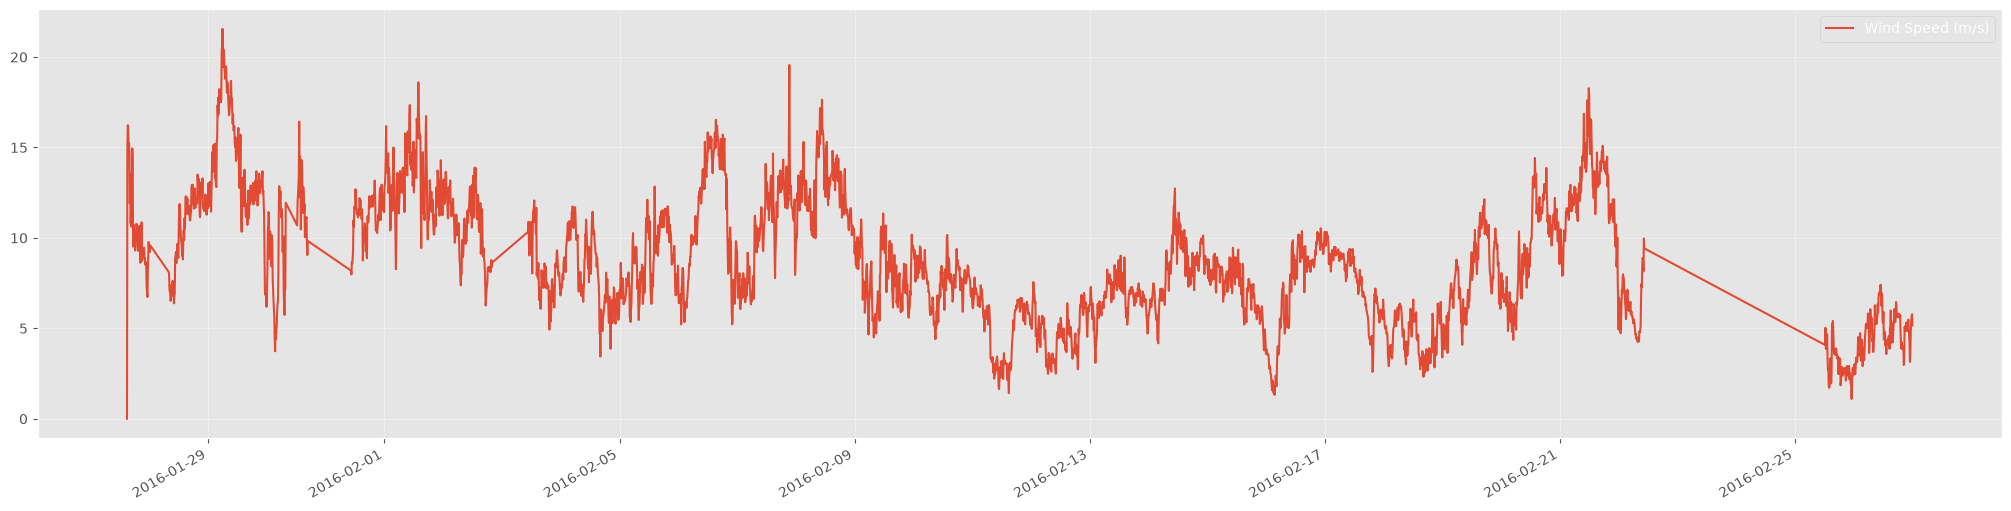

In [5]:
fig, ax = plt.subplots(figsize=(20, 5), constrained_layout=True)
df.plot(ax=ax);

The first observation is that there are gaps in the data, data loss for multiple period of times. When looking at the change in wind speed, we need to account for the gaps as the difference over a gap is not representative of the change in wind speed.

In [12]:
sampling_period = timedelta(seconds=10*60)
sampling_rate = 1 / sampling_period.total_seconds()
gaps = df.index.to_series().diff() > sampling_period
chunk_id = gaps.cumsum()

chunks = [chunk for _, chunk in df.groupby(chunk_id)]
print(f"Found {len(chunks)} chunks of data as a result of {len(chunks) - 1} gaps.")

Found 7 chunks of data as a result of 6 gaps.


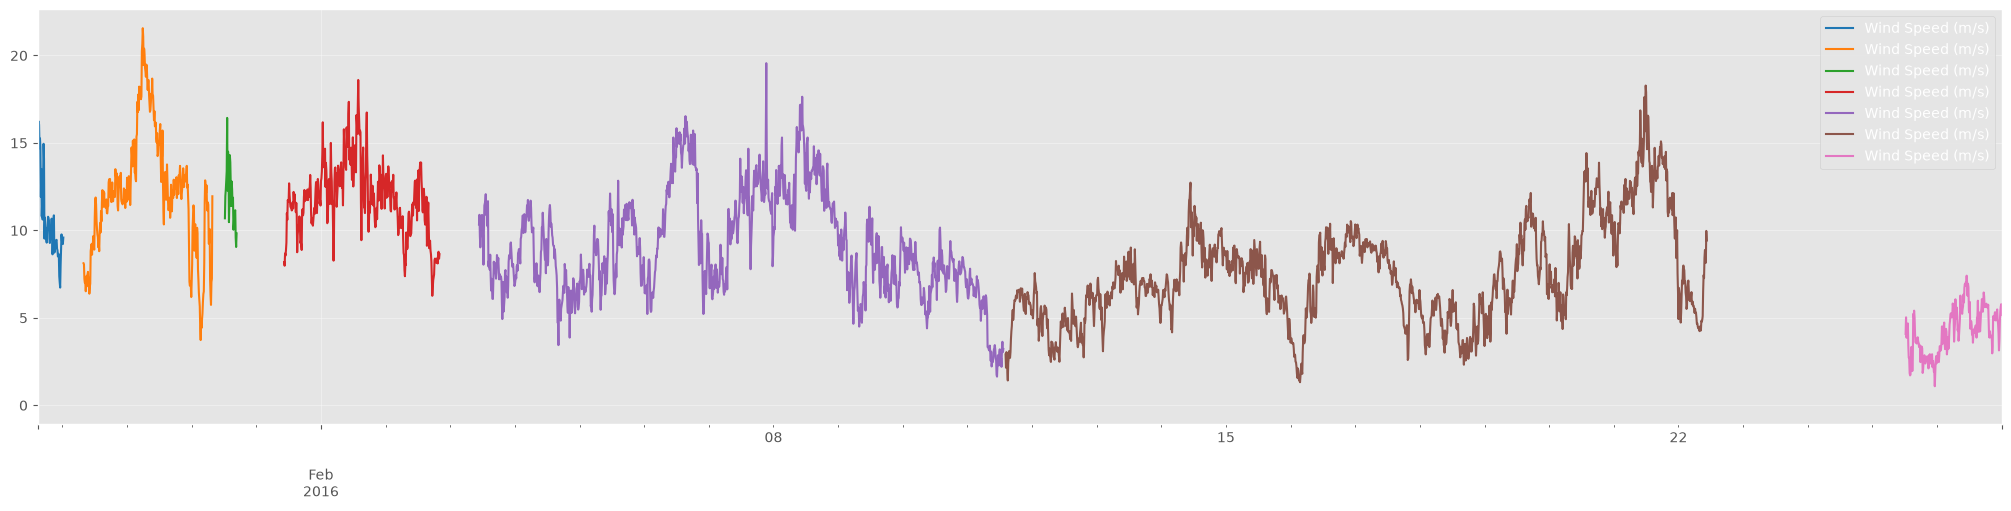

In [28]:
colormap = colormaps["tab10"]
fix, ax = plt.subplots(figsize=(20, 5), constrained_layout=True)
for no, chunk in enumerate(chunks):
    chunk.plot(ax=ax, color=colormap(no))